# Red Neuronal — MLPRegressor
Mismo pipeline que `regresion.ipynb`, usando `MLPRegressor` de sklearn para comparar resultados.

## Para utilizarlo con Colab (opcional)

In [1]:
# from google.colab import drive
# drive.mount('/content/drive')
# raiz="drive/MyDrive/proyecto_mineria/"
raiz=""

# Cargar datos y generar los conjuntos de entrenamiento y test

In [2]:
import pandas as pd

nombre_csv_logs = "red_neuronal_resultados"
file_path = f'{raiz}datasets_pkl/data_set_limpio_sin_not_for_sale.pkl'

df = pd.read_pickle(file_path)

print("shape: ", df.shape)
print(df.columns)
df.sample(n=5)

shape:  (186795, 70)
Index(['Nat', 'Division', 'Club', 'Based', 'Preferred Foot', 'Right Foot',
       'Left Foot', 'Position', 'Height', 'Weight', 'Age', 'Wage', 'AT Apps',
       'AT Gls', 'Team', 'Caps', 'Yth Apps', 'Style', 'Rc Injury', 'Best Role',
       'Best Duty', 'Best Pos', 'Acc', 'Aer', 'Agg', 'Agi', 'Ant', 'Bal',
       'Bra', 'Cmd', 'Com', 'Cmp', 'Cnt', 'Cor', 'Cro', 'Dec', 'Det', 'Dri',
       'Ecc', 'Fin', 'Fir', 'Fla', 'Fre', 'Han', 'Hea', 'Jum', 'Kic', 'Ldr',
       'Lon', 'L Th', 'Mar', 'Nat .1', 'OtB', '1v1', 'Pac', 'Pas', 'Pen',
       'Pos', 'Pun', 'Ref', 'TRO', 'Sta', 'Str', 'Tck', 'Tea', 'Tec', 'Thr',
       'Vis', 'Wor', 'transfer_value_estimado'],
      dtype='object')


,Nat,Division,Club,Based,Preferred Foot,Right Foot,Left Foot,Position,Height,Weight,...,TRO,Sta,Str,Tck,Tea,Tec,Thr,Vis,Wor,transfer_value_estimado
183244,FRA,French National 3 - Auvergne Rhône Alpes,Lyon - La Duchère,France (Nat 3 - Auvergne RA),Right,Very Strong,Weak,M (C),174,68,...,4,6,4,7,7,11,1,13,11,20000
30131,ECU,Ecuadorian LigaPro Serie A,Barcelona S.C.,Ecuador (LigaPro Serie A),Left,Weak,Very Strong,M/AM (L),176,67,...,4,7,5,4,8,14,2,6,10,32500
139174,NZL,New Zealand NRFL Division One,Waitematā,New Zealand (NRFL Division 1),Right,Very Strong,Weak,D (C),194,85,...,3,7,7,9,5,4,1,5,6,0
117093,SWE,Swedish Second Division Norrland,Friska Viljor FC,Sweden (Second Division N),Right,Very Strong,Reasonable,D (C),185,79,...,3,11,10,9,8,11,1,11,8,302500
31341,ARG,Argentine Second Division,Guillermo Brown (PM),Argentina (Second Division),Right Only,Very Strong,Very Weak,ST (C),183,77,...,4,7,9,5,6,11,3,4,7,412500


# Generar conjuntos de entrenamiento y test

In [3]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

## Aplicar clustering como feature engineering

In [4]:
import clustering as cl

kmeans_model_club     = cl.fit_kmeans(train_df, columna="Club")
kmeans_model_nat      = cl.fit_kmeans(train_df, columna="Nat")
kmeans_model_division = cl.fit_kmeans(train_df, columna="Division")

train_df = cl.apply_kmeans(train_df, kmeans_model_club)
train_df = cl.apply_kmeans(train_df, kmeans_model_nat)
train_df = cl.apply_kmeans(train_df, kmeans_model_division)

test_df = cl.apply_kmeans(test_df, kmeans_model_club)
test_df = cl.apply_kmeans(test_df, kmeans_model_nat)
test_df = cl.apply_kmeans(test_df, kmeans_model_division)

In [5]:
target = "transfer_value_estimado"

X_train = train_df.drop(columns=[target])
y_train = train_df[target]

X_test = test_df.drop(columns=[target])
y_test = test_df[target]

## One Hot Encoding para features categóricas

In [6]:
import numpy as np

categorical_cols = ["Nat_cluster", "Division_cluster", "Best Duty", "Style"]

X_train = pd.get_dummies(X_train, columns=categorical_cols)
X_test  = pd.get_dummies(X_test,  columns=categorical_cols)

X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

X_train = X_train.select_dtypes(include=[np.number, np.bool_])
X_test  = X_test.select_dtypes(include=[np.number, np.bool_])

## Escalado con StandardScaler

In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_test = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

print("Shape X_train:", X_train.shape)
print("Shape X_test: ", X_test.shape)

Shape X_train: (149436, 80)
Shape X_test:  (37359, 80)


# Función para registrar resultados

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import json
from sklearn.metrics import mean_absolute_error, mean_squared_error

def log_results(model, method_name, X_train, y_train, X_test, y_test,
                filepath=f"{raiz}{nombre_csv_logs}.csv"):
    params_dict = model.get_params()
    for k, v in params_dict.items():
        try:
            json.dumps(v)
        except TypeError:
            params_dict[k] = str(v)
    params = json.dumps(params_dict)

    y_pred = model.predict(X_test)

    r2_train = model.score(X_train, y_train)
    r2_test  = model.score(X_test,  y_test)
    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    row = {
        "method":          method_name,
        "hyperparameters": json.dumps(params),
        "r2_train":        r2_train,
        "r2_test":         r2_test,
        "mae":             mae,
        "rmse":            rmse
    }

    residuals = y_test - y_pred
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    sns.histplot(residuals, bins=50, kde=True, color="blue")
    plt.axvline(x=0, color='red', linestyle='--')
    plt.title("Residuals Distribution")
    plt.xlabel("Residuals")
    plt.ylabel("Frequency")

    plt.subplot(1, 2, 2)
    sns.scatterplot(x=y_test, y=y_pred, alpha=0.5)
    plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)],
             color='red', linestyle='--')
    plt.title("Regression Fit: Actual vs Predicted")
    plt.xlabel("Actual Transfer Values")
    plt.ylabel("Predicted Transfer Values")

    plt.suptitle(method_name, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print(f"  R² train : {r2_train:.4f}")
    print(f"  R² test  : {r2_test:.4f}")
    print(f"  MAE      : {mae:.2f}")
    print(f"  RMSE     : {rmse:.2f}")

    try:
        df_log = pd.read_csv(filepath)
        df_log = pd.concat([df_log, pd.DataFrame([row])], ignore_index=True)
    except FileNotFoundError:
        df_log = pd.DataFrame([row])

    df_log.to_csv(filepath, index=False)

# MLPRegressor
Red neuronal feedforward con una arquitectura fija.
Se usa `early_stopping=True` para evitar overfitting y `learning_rate='adaptive'` para estabilizar el entrenamiento.

In [9]:
from sklearn.neural_network import MLPRegressor

RS = 0

mlp_reg = MLPRegressor(
    hidden_layer_sizes=(256, 128, 64),  # 3 capas ocultas
    activation='relu',
    solver='adam',
    learning_rate='adaptive',
    learning_rate_init=0.001,
    max_iter=500,
    early_stopping=True,       # detiene el entrenamiento si no mejora
    validation_fraction=0.1,   # 10% del train se usa como validación
    n_iter_no_change=20,       # paciencia de 20 épocas sin mejora
    tol=1e-4,
    random_state=RS,
    verbose=False
)

mlp_reg.fit(X_train, y_train)
print(f"Iteraciones realizadas: {mlp_reg.n_iter_}")

Iteraciones realizadas: 110


## Curva de pérdida (loss curve)

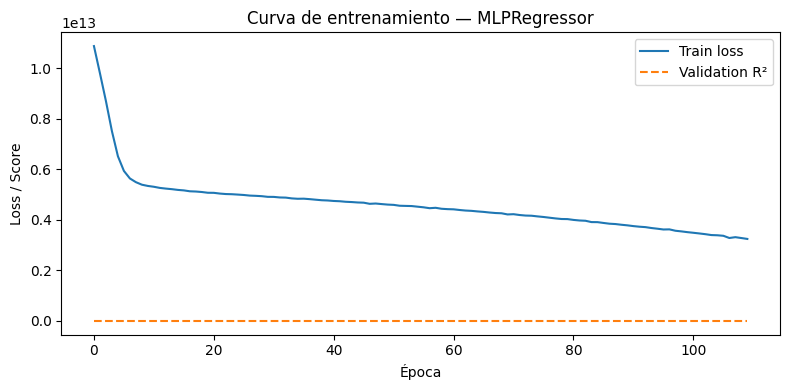

In [10]:
plt.figure(figsize=(8, 4))
plt.plot(mlp_reg.loss_curve_, label='Train loss')
if mlp_reg.best_validation_score_ is not None:
    plt.plot(mlp_reg.validation_scores_, label='Validation R²', linestyle='--')
plt.xlabel('Época')
plt.ylabel('Loss / Score')
plt.title('Curva de entrenamiento — MLPRegressor')
plt.legend()
plt.tight_layout()
plt.show()

## Métricas y gráficos

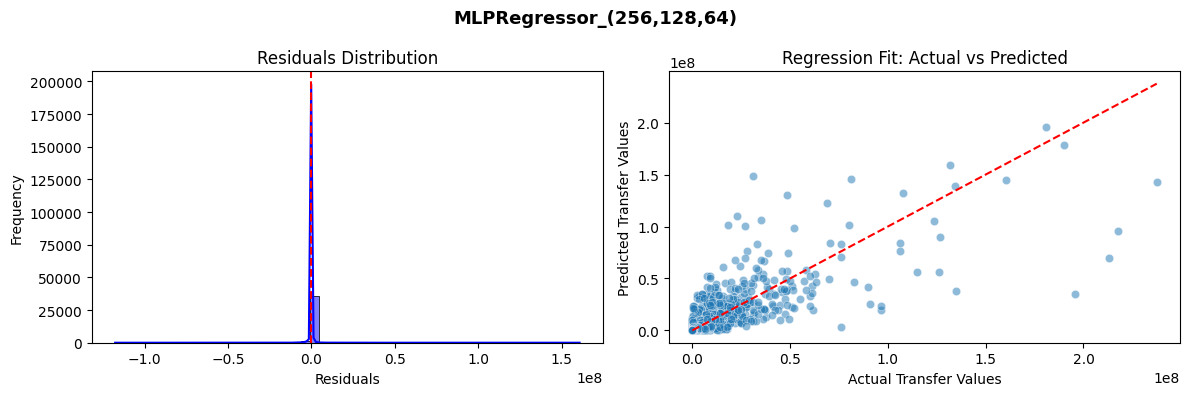

  R² train : 0.6591
  R² test  : 0.6140
  MAE      : 384432.98
  RMSE     : 2781826.66


In [11]:
log_results(mlp_reg, "MLPRegressor_(256,128,64)", X_train, y_train, X_test, y_test)

# Comparación con resultados de regresion.ipynb
Carga el CSV de métricas generado en `regresion.ipynb` y lo combina con el resultado de la red neuronal para comparar todos los modelos.

In [12]:
csv_regresion    = f"{raiz}presentacion1_resultados.csv"
csv_red_neuronal = f"{raiz}{nombre_csv_logs}.csv"

try:
    df_reg = pd.read_csv(csv_regresion)
    df_nn  = pd.read_csv(csv_red_neuronal)
    df_comparacion = pd.concat([df_reg, df_nn], ignore_index=True)
except FileNotFoundError as e:
    print(f"Archivo no encontrado: {e}")
    df_comparacion = pd.read_csv(csv_red_neuronal)

df_comparacion[["method", "r2_train", "r2_test", "mae", "rmse"]]

,method,r2_train,r2_test,mae,rmse
0,LinearRegression,0.465493,0.485584,613012.771484,3.211597e+06
1,RidgeCV,0.465493,0.485599,613005.945981,3.211550e+06
2,LassoCV,0.465170,0.486032,586993.300225,3.210198e+06
3,ElasticNetCV,0.000548,0.000634,777606.030785,4.476368e+06
4,LinearRegression,0.465493,0.485584,613012.771484,3.211597e+06
5,RidgeCV,0.465493,0.485599,613005.945981,3.211550e+06
6,LassoCV,0.465170,0.486032,586993.300225,3.210198e+06
7,ElasticNetCV,0.000548,0.000634,777606.030785,4.476368e+06
8,"MLPRegressor_(256,128,64)",0.659105,0.614048,384432.975585,2.781827e+06


## Gráfico comparativo de R² test

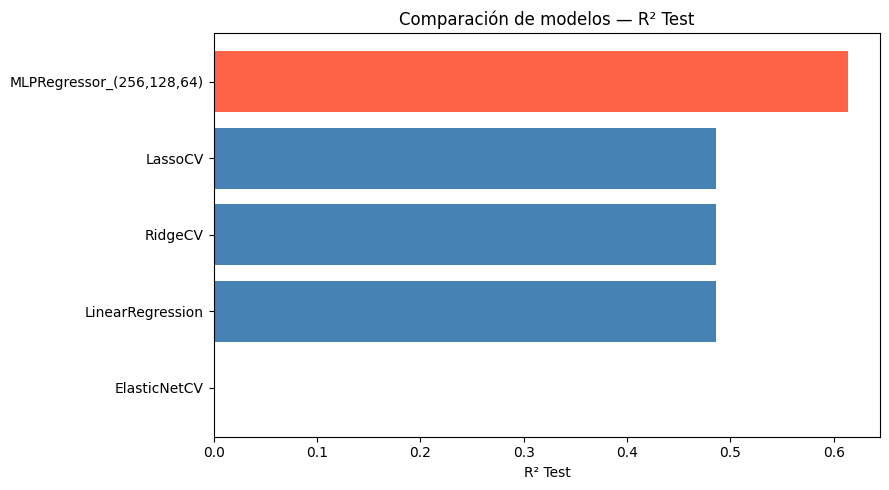

In [13]:
df_comp_sorted = df_comparacion.sort_values("r2_test", ascending=True)

colors = [
    "steelblue" if "MLP" not in m else "tomato"
    for m in df_comp_sorted["method"]
]

plt.figure(figsize=(9, 5))
plt.barh(df_comp_sorted["method"], df_comp_sorted["r2_test"], color=colors)
plt.xlabel("R² Test")
plt.title("Comparación de modelos — R² Test")
plt.tight_layout()
plt.show()

## Gráfico comparativo de RMSE

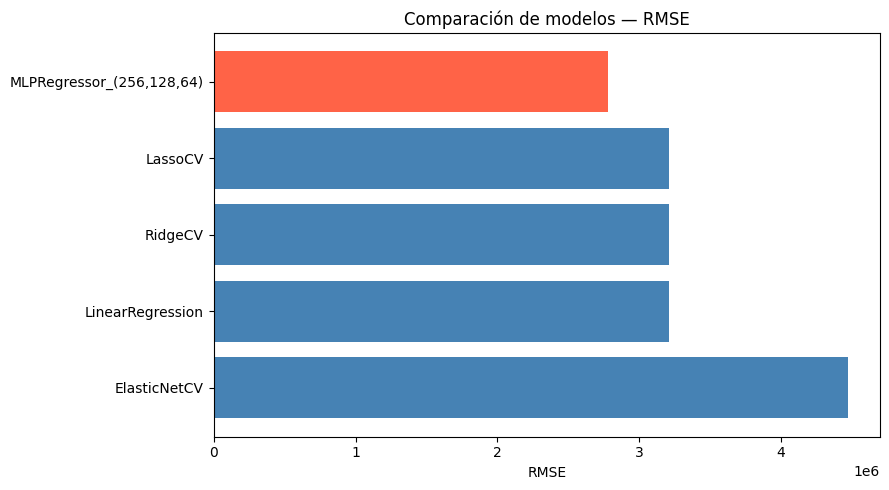

In [14]:
df_comp_sorted_rmse = df_comparacion.sort_values("rmse", ascending=False)

colors_rmse = [
    "steelblue" if "MLP" not in m else "tomato"
    for m in df_comp_sorted_rmse["method"]
]

plt.figure(figsize=(9, 5))
plt.barh(df_comp_sorted_rmse["method"], df_comp_sorted_rmse["rmse"], color=colors_rmse)
plt.xlabel("RMSE")
plt.title("Comparación de modelos — RMSE")
plt.tight_layout()
plt.show()